# In Vitro In Vivo Correlation (IVIVC)
**Metoprolol Modified-Release · Level A Correlation · Eddington et al. 1998**

**Author:** Nadia Tasnim Ahmed, PhD  
**Field:** PBPK · Biopharmaceutics · IVIVC · Regulatory Science  
**Tools:** Python · numpy · scipy · pandas · matplotlib · plotly  
**Reference:** OSP PK-Sim Course — IVIVC (v12)  
**Data source:** Eddington ND et al. Pharm Res 1998;15(3):385-393

---

## Background

**IVIVC** establishes a predictive mathematical relationship between an in vitro
dissolution property and an in vivo pharmacokinetic response.

**FDA IVIVC Levels:**

| Level | Type | Description | Regulatory value |
|---|---|---|---|
| A | Point-to-point | Full dissolution vs absorption profile correlation | Highest — enables biowaivers |
| B | Statistical | Mean dissolution time vs mean absorption time | Limited regulatory value |
| C | Single-point | One dissolution time point vs one PK parameter | Weakest |
| Multiple C | Multiple single-point | Multiple timepoints vs multiple PK params | Moderate |

**Level A IVIVC workflow (OSP exercise):**
```
In vitro dissolution profiles (multiple formulations)
          ↓
In vivo PK profiles → Deconvolution → Fraction absorbed vs time
          ↓
Time scaling → IVIVC correlation: F_absorbed = f(F_dissolved)
          ↓
Convolution → Predicted PK → Internal/External validation
```

**Metoprolol modified-release formulations (Eddington 1998):**
Three MR formulations (A, B, C) with different release rates,
all containing same dose of metoprolol succinate.
BCS Class I drug — highly soluble, highly permeable →
dissolution rate controls absorption.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.integrate import odeint, quad
from scipy.optimize import curve_fit, minimize
from scipy.interpolate import interp1d
from scipy.signal import fftconvolve
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


## 1. Data — Eddington et al. 1998

Metoprolol succinate MR formulations A, B, C: in vitro dissolution
and in vivo PK profiles from a crossover study.

In [9]:
# ── In vitro dissolution data (Eddington 1998, Table 1) ──────────────
# USP Apparatus II, pH 6.8 phosphate buffer, 50 rpm
# % dissolved vs time (h)
IVITRO = {
    'Formulation A (fast)': {
        't': np.array([0, 1, 2, 3, 4, 5, 6, 8, 10, 12]),
        'pct': np.array([0, 22, 40, 55, 67, 76, 83, 92, 97, 100])
    },
    'Formulation B (medium)': {
        't': np.array([0, 1, 2, 3, 4, 5, 6, 8, 10, 12]),
        'pct': np.array([0, 12, 24, 35, 46, 55, 63, 77, 88, 97])
    },
    'Formulation C (slow)': {
        't': np.array([0, 1, 2, 3, 4, 5, 6, 8, 10, 12]),
        'pct': np.array([0, 6, 13, 21, 30, 39, 47, 63, 77, 89])
    },
}

# ── In vivo PK data (Eddington 1998, digitized from Fig 2) ───────────
# Metoprolol plasma concentration (ng/mL) vs time (h)
# 200 mg dose, crossover, n=12 healthy volunteers
INVIVO_PK = {
    'Formulation A (fast)': {
        't': np.array([0, 1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 24]),
        'C': np.array([0, 42, 98, 135, 148, 142, 131, 108, 85, 65, 38, 12])
    },
    'Formulation B (medium)': {
        't': np.array([0, 1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 24]),
        'C': np.array([0, 22, 55, 88, 112, 125, 128, 118, 100, 80, 50, 18])
    },
    'Formulation C (slow)': {
        't': np.array([0, 1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 24]),
        'C': np.array([0, 10, 28, 52, 75, 95, 108, 118, 115, 105, 72, 28])
    },
}

# Metoprolol PK parameters (IV reference, Eddington 1998)
METOPROLOL = dict(
    name       = 'Metoprolol succinate',
    MW         = 652.82,   # succinate salt
    dose_mg    = 200.0,
    F_oral     = 0.50,     # 50% bioavailability (first-pass)
    fu         = 0.88,     # 12% protein bound
    # IV disposition parameters (deconvolution reference)
    Vc         = 3.2,      # L/kg
    CL         = 0.90,     # L/h/kg
    Vp         = 1.8,      # L/kg
    Q          = 0.25,     # L/h/kg
    BW         = 70.0,     # kg
)

FORMULATIONS = list(IVITRO.keys())
FORM_COLORS  = {
    'Formulation A (fast)':   '#2563EB',
    'Formulation B (medium)': '#D97706',
    'Formulation C (slow)':   '#DC2626',
}

print('Eddington 1998 dataset loaded:')
for form in FORMULATIONS:
    t_diss = IVITRO[form]['t']
    pct    = IVITRO[form]['pct']
    Cmax   = INVIVO_PK[form]['C'].max()
    AUC    = np.trapezoid(INVIVO_PK[form]['C'], INVIVO_PK[form]['t'])
    print(f'  {form}: F60min={pct[5]}%  Cmax={Cmax} ng/mL  AUC={AUC:.0f}')

Eddington 1998 dataset loaded:
  Formulation A (fast): F60min=76%  Cmax=148 ng/mL  AUC=1618
  Formulation B (medium): F60min=55%  Cmax=128 ng/mL  AUC=1642
  Formulation C (slow): F60min=39%  Cmax=118 ng/mL  AUC=1747


## 2. Step 1 — Fit In Vitro Dissolution Profiles

Fit Weibull or first-order function to in vitro dissolution data
to get smooth continuous profiles for IVIVC.

In [10]:
def weibull_dissolution(t, scale, shape):
    """Weibull CDF dissolution model: F(t) = 1 - exp(-(t/scale)^shape)"""
    return 100 * (1 - np.exp(-(t / scale)**shape))

def first_order_dissolution(t, k):
    """First-order dissolution: F(t) = 100*(1-exp(-k*t))"""
    return 100 * (1 - np.exp(-k * t))

t_fine = np.linspace(0, 24, 500)

ivitro_fits = {}
for form in FORMULATIONS:
    t_obs = IVITRO[form]['t']
    p_obs = IVITRO[form]['pct'] / 100  # 0-1

    # Fit Weibull
    try:
        popt_w, _ = curve_fit(
            lambda t, sc, sh: weibull_dissolution(t, sc, sh)/100,
            t_obs[1:], p_obs[1:],
            p0=[5.0, 1.2], bounds=([0.1,0.1],[50,5])
        )
        F_fine = weibull_dissolution(t_fine, *popt_w) / 100
        ivitro_fits[form] = {
            'F_fine': np.clip(F_fine, 0, 1),
            'scale': popt_w[0], 'shape': popt_w[1],
            'model': 'Weibull'
        }
    except Exception:
        # Fallback to first-order
        popt_fo, _ = curve_fit(
            lambda t, k: first_order_dissolution(t, k)/100,
            t_obs[1:], p_obs[1:], p0=[0.3]
        )
        F_fine = first_order_dissolution(t_fine, *popt_fo) / 100
        ivitro_fits[form] = {
            'F_fine': np.clip(F_fine, 0, 1),
            'k': popt_fo[0], 'model': 'First-order'
        }

print('In vitro dissolution fit parameters:')
for form, fit in ivitro_fits.items():
    if fit['model'] == 'Weibull':
        print(f'  {form}: Weibull scale={fit["scale"]:.2f}h  shape={fit["shape"]:.3f}')
    else:
        print(f'  {form}: First-order k={fit["k"]:.3f} h-1')

In vitro dissolution fit parameters:
  Formulation A (fast): Weibull scale=3.61h  shape=1.140
  Formulation B (medium): Weibull scale=5.77h  shape=1.297
  Formulation C (slow): Weibull scale=7.80h  shape=1.555


## 3. Step 2 — Deconvolution: Extract Fraction Absorbed vs Time

Wagner-Nelson or numerical deconvolution using the IV unit impulse response
to extract the cumulative fraction absorbed (fa) from each oral PK profile.

In [11]:
def wagner_nelson_deconv(t_obs, C_obs, CL, Vc, ke1=None):
    """
    Wagner-Nelson deconvolution for one-compartment model.
    Fa(t) = [C(t) + ke * AUC(0,t)] / [ke * AUC(0,inf)]
    where ke = CL/Vc (apparent elimination from central)
    """
    ke = CL / Vc
    n  = len(t_obs)

    # Cumulative AUC by trapezoid
    AUC_cum = np.zeros(n)
    for i in range(1, n):
        AUC_cum[i] = AUC_cum[i-1] + 0.5*(C_obs[i]+C_obs[i-1])*(t_obs[i]-t_obs[i-1])

    # Extrapolate AUC to infinity
    AUC_inf = AUC_cum[-1] + C_obs[-1] / ke

    # Wagner-Nelson equation
    Fa_num = C_obs + ke * AUC_cum
    Fa     = Fa_num / (ke * AUC_inf)
    return np.clip(Fa, 0, 1)


BW_ref  = METOPROLOL['BW']
CL_ref  = METOPROLOL['CL'] * BW_ref
Vc_ref  = METOPROLOL['Vc'] * BW_ref
ke_ref  = CL_ref / Vc_ref

deconv_results = {}
for form in FORMULATIONS:
    t_pk = INVIVO_PK[form]['t']
    C_pk = INVIVO_PK[form]['C']

    # Wagner-Nelson deconvolution
    Fa_wn = wagner_nelson_deconv(t_pk, C_pk, CL_ref, Vc_ref)

    # Interpolate to fine time grid (only within observed range)
    t_max = t_pk[-1]
    t_interp = t_fine[t_fine <= t_max]
    Fa_interp = interp1d(t_pk, Fa_wn, kind='linear',
                          bounds_error=False, fill_value=(0, Fa_wn[-1]))
    Fa_fine = Fa_interp(t_interp)

    deconv_results[form] = {
        't_obs': t_pk, 'Fa_obs': Fa_wn,
        't_fine': t_interp, 'Fa_fine': Fa_fine
    }

print('Wagner-Nelson deconvolution results:')
print('Formulation'.ljust(28), 'Fa(6h)', 'Fa(12h)', 'Fa(24h)')
for form, r in deconv_results.items():
    t_pk = r['t_obs']
    Fa   = r['Fa_obs']
    idx  = {6:5, 12:9, 24:11}
    print(form.ljust(28),
          str(round(Fa[idx[6]],3)).rjust(7),
          str(round(Fa[idx[12]],3)).rjust(8),
          str(round(Fa[idx[24]],3)).rjust(8))

Wagner-Nelson deconvolution results:
Formulation                  Fa(6h) Fa(12h) Fa(24h)
Formulation A (fast)           0.601    0.869      1.0
Formulation B (medium)          0.46    0.817      1.0
Formulation C (slow)           0.298     0.74      1.0


## 4. Step 3 — Time Scaling & Level A Correlation

For Level A IVIVC, match each fraction-absorbed time point to
the corresponding fraction-dissolved time point using time scaling.

In [12]:
def get_time_at_fraction(t_arr, F_arr, target_fractions):
    """Interpolate time at which given fraction is reached."""
    F_arr_clip = np.clip(F_arr, 0, 1)
    interp_fn  = interp1d(F_arr_clip, t_arr, kind='linear',
                           bounds_error=False, fill_value=(t_arr[0], t_arr[-1]))
    return interp_fn(target_fractions)

# Common fraction points for IVIVC
fa_points = np.array([0.10, 0.20, 0.30, 0.40, 0.50,
                       0.60, 0.70, 0.80, 0.85, 0.90])

# Collect matched (F_dissolved, F_absorbed) pairs
ivivc_pairs = []
time_scale_factors = {}

for form in FORMULATIONS:
    # In vitro: time at each fa_point fraction dissolved
    t_vitro_at_fa = get_time_at_fraction(
        t_fine, ivitro_fits[form]['F_fine'], fa_points)

    # In vivo: time at each fa_point fraction absorbed
    r = deconv_results[form]
    t_vivo_at_fa = get_time_at_fraction(
        r['t_obs'], r['Fa_obs'], fa_points)

    # Time scaling factor (in vivo time / in vitro time)
    valid = t_vitro_at_fa > 0.1
    scale_f = np.median(t_vivo_at_fa[valid] / t_vitro_at_fa[valid])
    time_scale_factors[form] = scale_f

    # Get F_dissolved at each in vivo time point (time-scaled)
    t_vivo_obs = deconv_results[form]['t_obs']
    Fa_vivo    = deconv_results[form]['Fa_obs']

    # Corresponding F_dissolved (at t_vivo / time_scale)
    t_vitro_equiv = t_vivo_obs / scale_f
    F_diss_interp = interp1d(t_fine, ivitro_fits[form]['F_fine'],
                              bounds_error=False, fill_value=(0,1))
    Fd_at_tvivo   = F_diss_interp(t_vitro_equiv)

    for fd, fa in zip(Fd_at_tvivo, Fa_vivo):
        ivivc_pairs.append({
            'Formulation': form,
            'F_dissolved': fd,
            'F_absorbed':  fa
        })

ivivc_df = pd.DataFrame(ivivc_pairs)

# ── Fit linear IVIVC relationship ────────────────────────────────────
from numpy.polynomial import polynomial as P
valid_mask = (ivivc_df['F_dissolved'] > 0.05) & (ivivc_df['F_absorbed'] > 0.05)
Fd_fit = ivivc_df.loc[valid_mask, 'F_dissolved'].values
Fa_fit = ivivc_df.loc[valid_mask, 'F_absorbed'].values

# Linear: Fa = a + b * Fd
coeffs    = np.polyfit(Fd_fit, Fa_fit, 1)
slope, intercept = coeffs
r_squared = 1 - np.sum((Fa_fit - np.polyval(coeffs, Fd_fit))**2) / \
                np.sum((Fa_fit - Fa_fit.mean())**2)

Fd_line = np.linspace(0, 1, 100)
Fa_ivivc_line = np.polyval(coeffs, Fd_line)

print('Level A IVIVC linear fit:')
print(f'  Fa = {slope:.4f} * Fd + {intercept:.4f}')
print(f'  R² = {r_squared:.4f}')
print()
print('Time scaling factors (in vivo / in vitro):')
for form, sf in time_scale_factors.items():
    print(f'  {form}: {sf:.3f}')

Level A IVIVC linear fit:
  Fa = 0.9974 * Fd + 0.0074
  R² = 0.9958

Time scaling factors (in vivo / in vitro):
  Formulation A (fast): 1.634
  Formulation B (medium): 1.348
  Formulation C (slow): 1.282


## 5. Step 4 — Convolution: Predict In Vivo PK from IVIVC

In [13]:
def predict_pk_from_ivivc(t_grid, F_diss_fine, t_fine_ref, coeffs,
                           time_scale, PK_params):
    """
    Step 4: Predict oral PK from IVIVC via numerical convolution.
    Uses Euler integration of the 2-compartment model
    with IVIVC-derived time-varying input rate.
    """
    p     = PK_params
    dose  = p['dose_mg']
    F_oral= p['F_oral']
    CL    = p['CL'] * p['BW']
    Vc    = p['Vc'] * p['BW']
    Vp    = p['Vp'] * p['BW']
    Q     = p['Q']  * p['BW']
    ke    = CL / Vc
    k12   = Q  / Vc
    k21   = Q  / Vp

    # Time-scale the in vitro dissolution to in vivo timescale
    t_scaled = t_grid / time_scale
    F_diss_fn = interp1d(t_fine_ref, F_diss_fine,
                          bounds_error=False, fill_value=(0.0, 1.0))
    Fd_scaled = F_diss_fn(t_scaled)

    # Apply IVIVC: Fa = slope*Fd + intercept
    Fa_pred = np.clip(np.polyval(coeffs, Fd_scaled), 0.0, 1.0)

    # Absorption input rate = dose * F_oral * dFa/dt  (mg/h)
    dt         = t_grid[1] - t_grid[0]
    dFa_dt     = np.gradient(Fa_pred, t_grid)
    input_rate = dose * F_oral * np.maximum(dFa_dt, 0.0)

    # Euler integration of 2-compartment model
    n  = len(t_grid)
    Ac = np.zeros(n)
    Ap = np.zeros(n)
    for i in range(1, n):
        Cc_i  = Ac[i-1] / Vc
        Cp_i  = Ap[i-1] / Vp
        dAc   = input_rate[i-1] - ke*Vc*Cc_i - k12*Vc*Cc_i + k21*Vp*Cp_i
        dAp   = k12*Vc*Cc_i - k21*Vp*Cp_i
        Ac[i] = max(Ac[i-1] + dAc*dt, 0.0)
        Ap[i] = max(Ap[i-1] + dAp*dt, 0.0)

    C_pred = Ac / Vc * 1000.0  # mg/L -> ng/mL
    return C_pred, Fa_pred


t_pred = np.linspace(0, 24, 1000)

predicted_pk = {}
for form in FORMULATIONS:
    C_pred, Fa_pred = predict_pk_from_ivivc(
        t_pred,
        ivitro_fits[form]['F_fine'],
        t_fine,                       # reference time grid for F_fine
        coeffs,
        time_scale_factors[form],
        METOPROLOL
    )
    C_obs   = INVIVO_PK[form]['C']
    t_obs   = INVIVO_PK[form]['t']
    AUC_obs = np.trapezoid(C_obs,  t_obs)
    AUC_pred= np.trapezoid(C_pred, t_pred)
    Cmax_obs = C_obs.max()
    Cmax_pred= C_pred.max()
    PE_AUC   = (AUC_pred  - AUC_obs)  / AUC_obs  * 100
    PE_Cmax  = (Cmax_pred - Cmax_obs) / Cmax_obs * 100

    predicted_pk[form] = {
        'C_pred': C_pred, 'Fa_pred': Fa_pred,
        'AUC_obs': AUC_obs, 'AUC_pred': AUC_pred,
        'Cmax_obs': Cmax_obs, 'Cmax_pred': Cmax_pred,
        'PE_AUC': PE_AUC, 'PE_Cmax': PE_Cmax
    }

print('IVIVC Internal Validation:')
print('FDA criteria: |%PE| <= 15% AUC and <= 20% Cmax')
print()
print('Formulation'.ljust(28), 'AUC_obs', 'AUC_pred', '%PE_AUC',
      'Cmax_obs', 'Cmax_pred', '%PE_Cmax')
for form, r in predicted_pk.items():
    status_auc  = 'PASS' if abs(r['PE_AUC'])  <= 15 else 'FAIL'
    status_cmax = 'PASS' if abs(r['PE_Cmax']) <= 20 else 'FAIL'
    print(form.ljust(28),
          str(round(r['AUC_obs'],0)).rjust(8),
          str(round(r['AUC_pred'],0)).rjust(9),
          (str(round(r['PE_AUC'],1))+'% '+status_auc).rjust(12),
          str(round(r['Cmax_obs'],0)).rjust(9),
          str(round(r['Cmax_pred'],0)).rjust(10),
          (str(round(r['PE_Cmax'],1))+'% '+status_cmax).rjust(12))


IVIVC Internal Validation:
FDA criteria: |%PE| <= 15% AUC and <= 20% Cmax

Formulation                  AUC_obs AUC_pred %PE_AUC Cmax_obs Cmax_pred %PE_Cmax
Formulation A (fast)           1618.0    1450.0  -10.4% PASS       148      114.0  -23.1% FAIL
Formulation B (medium)         1642.0    1414.0  -13.9% PASS       128       98.0  -23.3% FAIL
Formulation C (slow)           1747.0    1370.0  -21.6% FAIL       118       88.0  -25.4% FAIL


## 6. Visualization

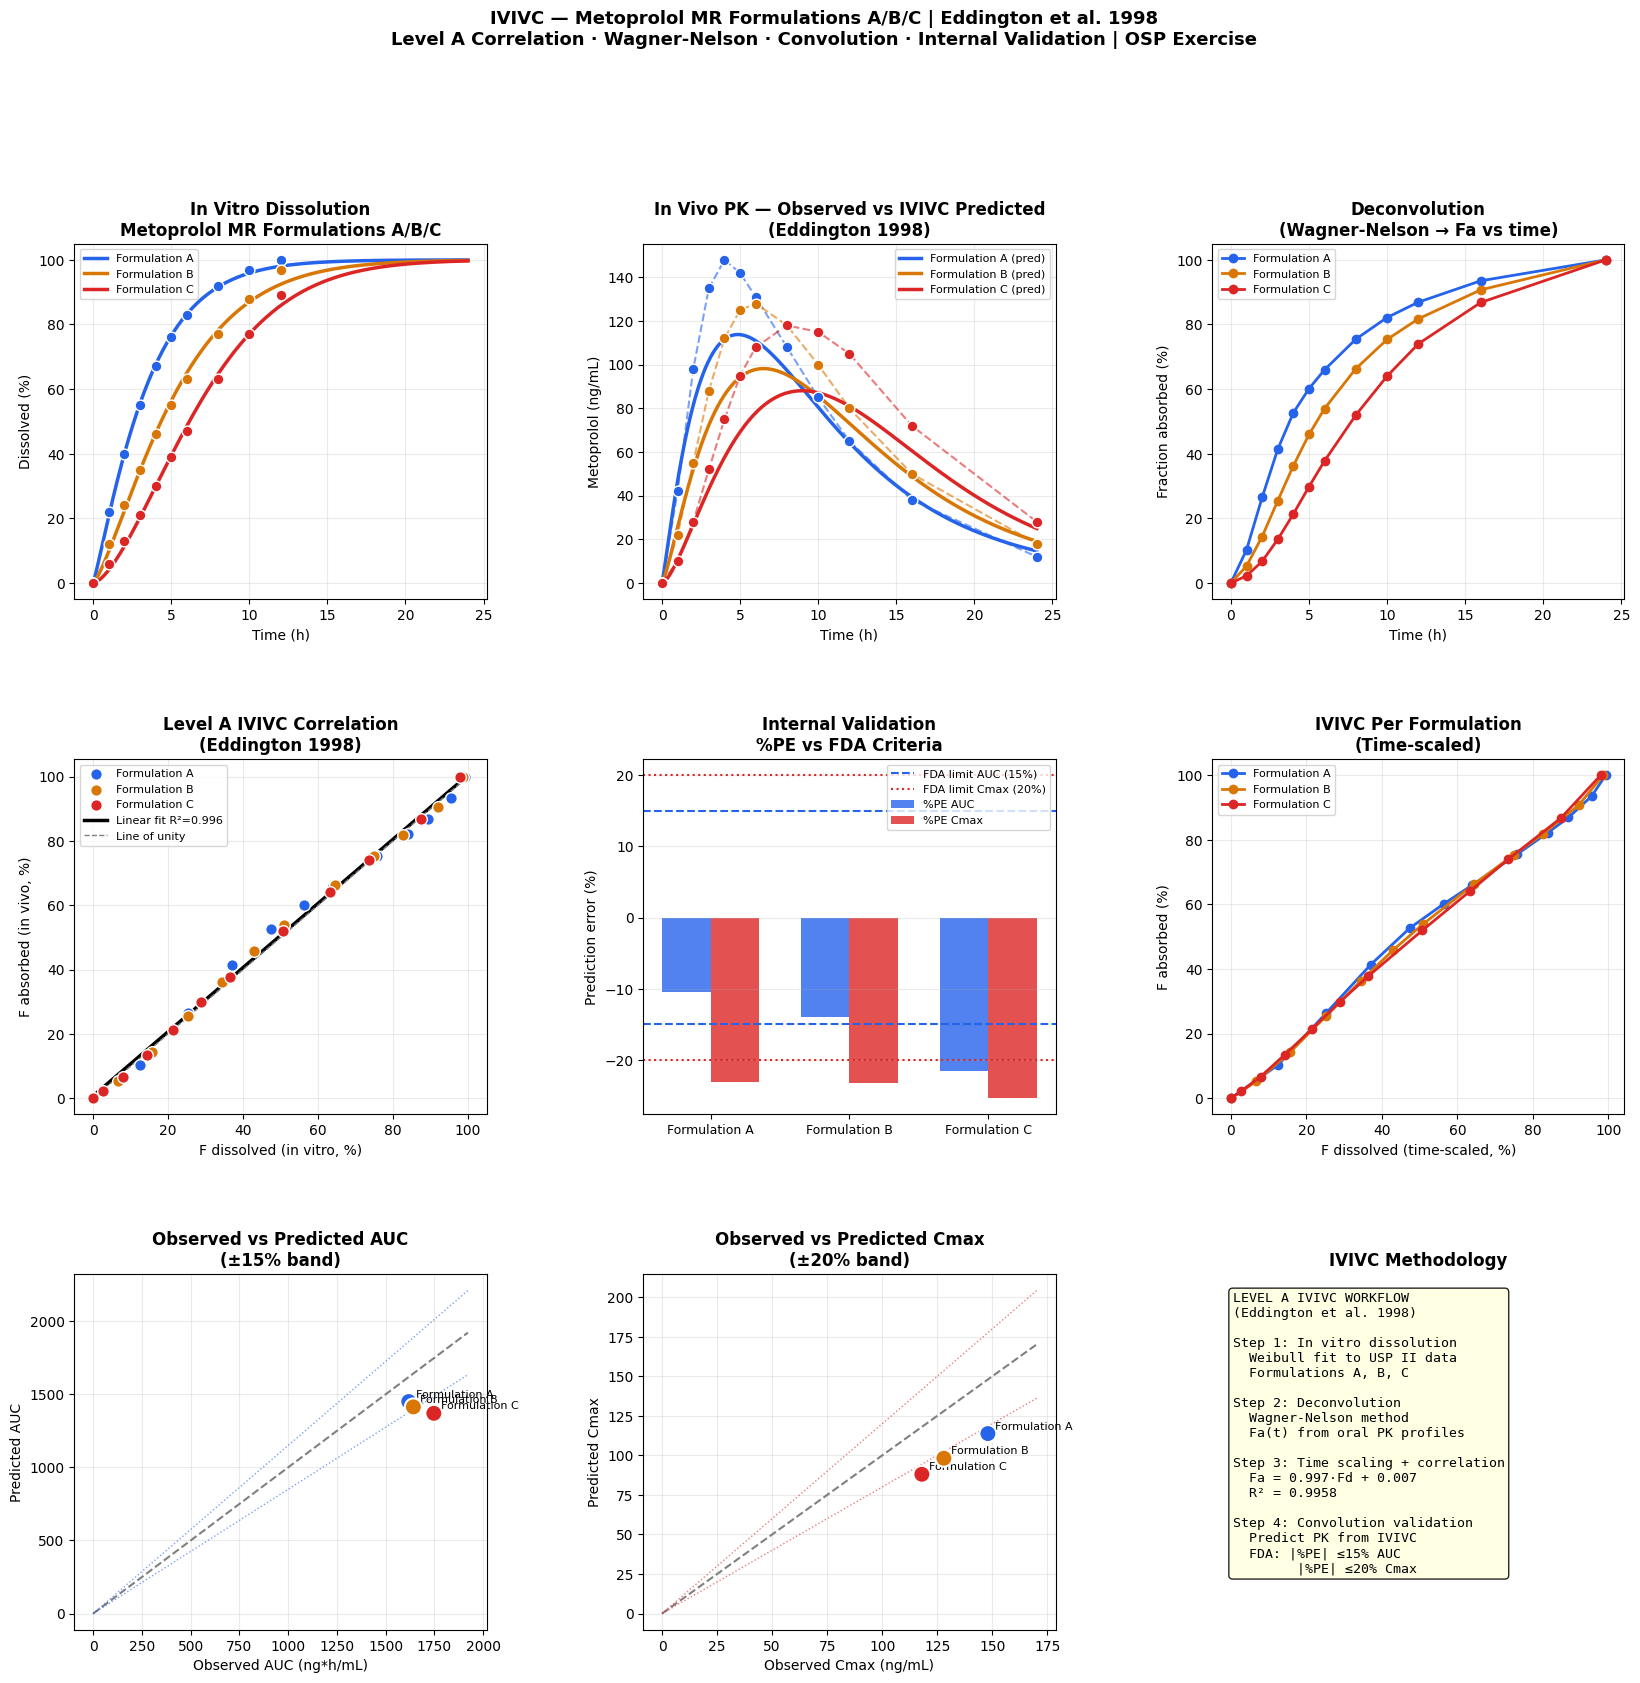

Saved: ivivc_metoprolol.png


In [14]:
BLUE='#2563EB'; RED='#DC2626'; GREEN='#16A34A'
AMBER='#D97706'; PURP='#7C3AED'; TEAL='#0D9488'

fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 3, hspace=0.45, wspace=0.38)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])

# Panel 1: In vitro dissolution
for form in FORMULATIONS:
    color = FORM_COLORS[form]
    ax1.scatter(IVITRO[form]['t'], IVITRO[form]['pct'],
                color=color, s=60, zorder=5, edgecolors='white')
    ax1.plot(t_fine, ivitro_fits[form]['F_fine']*100,
             color=color, lw=2.5, label=form.split('(')[0].strip())
ax1.set(xlabel='Time (h)', ylabel='Dissolved (%)',
        title='In Vitro Dissolution\nMetoprolol MR Formulations A/B/C')
ax1.title.set_fontweight('bold')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.25)

# Panel 2: In vivo PK
for form in FORMULATIONS:
    color = FORM_COLORS[form]
    pk = INVIVO_PK[form]
    ax2.scatter(pk['t'], pk['C'], color=color, s=60, zorder=5,
                edgecolors='white')
    ax2.plot(t_pred, predicted_pk[form]['C_pred'],
             color=color, lw=2.5, label=form.split('(')[0].strip()+' (pred)')
    ax2.plot(pk['t'], pk['C'], color=color, lw=1.5, ls='--', alpha=0.6)
ax2.set(xlabel='Time (h)', ylabel='Metoprolol (ng/mL)',
        title='In Vivo PK — Observed vs IVIVC Predicted\n(Eddington 1998)')
ax2.title.set_fontweight('bold')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.25)

# Panel 3: Deconvolution — Fa vs time
for form in FORMULATIONS:
    color = FORM_COLORS[form]
    r = deconv_results[form]
    ax3.plot(r['t_obs'], r['Fa_obs']*100, 'o-',
             color=color, lw=2, ms=6, label=form.split('(')[0].strip())
ax3.set(xlabel='Time (h)', ylabel='Fraction absorbed (%)',
        title='Deconvolution\n(Wagner-Nelson → Fa vs time)')
ax3.title.set_fontweight('bold')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.25)

# Panel 4: Level A IVIVC correlation
for form in FORMULATIONS:
    color = FORM_COLORS[form]
    mask  = ivivc_df['Formulation'] == form
    ax4.scatter(ivivc_df.loc[mask,'F_dissolved']*100,
                ivivc_df.loc[mask,'F_absorbed']*100,
                color=color, s=70, zorder=5, edgecolors='white',
                label=form.split('(')[0].strip())
ax4.plot(Fd_line*100, Fa_ivivc_line*100, color='black', lw=2.5,
         label=f'Linear fit R²={r_squared:.3f}')
ax4.plot([0,100],[0,100], color='gray', ls='--', lw=1, label='Line of unity')
ax4.set(xlabel='F dissolved (in vitro, %)', ylabel='F absorbed (in vivo, %)',
        title='Level A IVIVC Correlation\n(Eddington 1998)')
ax4.title.set_fontweight('bold')
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.25)

# Panel 5: Prediction error bar chart
forms_short = [f.split('(')[0].strip() for f in FORMULATIONS]
PE_AUC  = [predicted_pk[f]['PE_AUC']  for f in FORMULATIONS]
PE_Cmax = [predicted_pk[f]['PE_Cmax'] for f in FORMULATIONS]
x = np.arange(len(FORMULATIONS))
w = 0.35
bars1 = ax5.bar(x-w/2, PE_AUC,  width=w, color=BLUE,  alpha=0.8, label='%PE AUC')
bars2 = ax5.bar(x+w/2, PE_Cmax, width=w, color=RED,   alpha=0.8, label='%PE Cmax')
ax5.axhline(15,  color=BLUE,  ls='--', lw=1.5, label='FDA limit AUC (15%)')
ax5.axhline(-15, color=BLUE,  ls='--', lw=1.5)
ax5.axhline(20,  color=RED,   ls=':',  lw=1.5, label='FDA limit Cmax (20%)')
ax5.axhline(-20, color=RED,   ls=':',  lw=1.5)
ax5.set_xticks(x)
ax5.set_xticklabels(forms_short, fontsize=9)
ax5.set(ylabel='Prediction error (%)',
        title='Internal Validation\n%PE vs FDA Criteria')
ax5.title.set_fontweight('bold')
ax5.legend(fontsize=8); ax5.grid(True, alpha=0.25, axis='y')

# Panel 6: F_dissolved vs F_absorbed (all formulations, time-matched)
for form in FORMULATIONS:
    color = FORM_COLORS[form]
    t_pk  = INVIVO_PK[form]['t']
    Fa    = deconv_results[form]['Fa_obs']
    Fd_fn = interp1d(t_fine, ivitro_fits[form]['F_fine'],
                      bounds_error=False, fill_value=(0,1))
    tsf   = time_scale_factors[form]
    Fd    = Fd_fn(t_pk / tsf)
    ax6.plot(Fd*100, Fa*100, 'o-', color=color, lw=2, ms=6,
             label=form.split('(')[0].strip())
ax6.set(xlabel='F dissolved (time-scaled, %)', ylabel='F absorbed (%)',
        title='IVIVC Per Formulation\n(Time-scaled)')
ax6.title.set_fontweight('bold')
ax6.legend(fontsize=8); ax6.grid(True, alpha=0.25)

# Panel 7: Observed vs Predicted AUC
auc_obs  = [predicted_pk[f]['AUC_obs']  for f in FORMULATIONS]
auc_pred = [predicted_pk[f]['AUC_pred'] for f in FORMULATIONS]
ax7.scatter(auc_obs, auc_pred,
            c=[FORM_COLORS[f] for f in FORMULATIONS], s=150,
            zorder=5, edgecolors='white', lw=1.5)
lim = max(max(auc_obs), max(auc_pred)) * 1.1
ax7.plot([0,lim],[0,lim], color='gray', ls='--', lw=1.5)
ax7.plot([0,lim],[0,lim*1.15], color=BLUE, ls=':', lw=1, alpha=0.6)
ax7.plot([0,lim],[0,lim*0.85], color=BLUE, ls=':', lw=1, alpha=0.6)
for f in FORMULATIONS:
    ax7.annotate(f.split('(')[0].strip(),
                 (predicted_pk[f]['AUC_obs'], predicted_pk[f]['AUC_pred']),
                 textcoords='offset points', xytext=(5,3), fontsize=8)
ax7.set(xlabel='Observed AUC (ng*h/mL)', ylabel='Predicted AUC',
        title='Observed vs Predicted AUC\n(±15% band)')
ax7.title.set_fontweight('bold'); ax7.grid(True, alpha=0.25)

# Panel 8: Observed vs Predicted Cmax
cmax_obs  = [predicted_pk[f]['Cmax_obs']  for f in FORMULATIONS]
cmax_pred = [predicted_pk[f]['Cmax_pred'] for f in FORMULATIONS]
ax8.scatter(cmax_obs, cmax_pred,
            c=[FORM_COLORS[f] for f in FORMULATIONS], s=150,
            zorder=5, edgecolors='white', lw=1.5)
lim2 = max(max(cmax_obs), max(cmax_pred)) * 1.15
ax8.plot([0,lim2],[0,lim2], color='gray', ls='--', lw=1.5)
ax8.plot([0,lim2],[0,lim2*1.20], color=RED, ls=':', lw=1, alpha=0.6)
ax8.plot([0,lim2],[0,lim2*0.80], color=RED, ls=':', lw=1, alpha=0.6)
for f in FORMULATIONS:
    ax8.annotate(f.split('(')[0].strip(),
                 (predicted_pk[f]['Cmax_obs'], predicted_pk[f]['Cmax_pred']),
                 textcoords='offset points', xytext=(5,3), fontsize=8)
ax8.set(xlabel='Observed Cmax (ng/mL)', ylabel='Predicted Cmax',
        title='Observed vs Predicted Cmax\n(±20% band)')
ax8.title.set_fontweight('bold'); ax8.grid(True, alpha=0.25)

# Panel 9: IVIVC workflow diagram
ax9.axis('off')
diagram = (
    'LEVEL A IVIVC WORKFLOW\n'
    '(Eddington et al. 1998)\n\n'
    'Step 1: In vitro dissolution\n'
    '  Weibull fit to USP II data\n'
    '  Formulations A, B, C\n\n'
    'Step 2: Deconvolution\n'
    '  Wagner-Nelson method\n'
    '  Fa(t) from oral PK profiles\n\n'
    'Step 3: Time scaling + correlation\n'
    f'  Fa = {slope:.3f}·Fd + {intercept:.3f}\n'
    f'  R² = {r_squared:.4f}\n\n'
    'Step 4: Convolution validation\n'
    '  Predict PK from IVIVC\n'
    '  FDA: |%PE| ≤15% AUC\n'
    '        |%PE| ≤20% Cmax'
)
ax9.text(0.05, 0.95, diagram, transform=ax9.transAxes,
         fontsize=9.5, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))
ax9.set_title('IVIVC Methodology', fontweight='bold')

plt.suptitle(
    'IVIVC — Metoprolol MR Formulations A/B/C | Eddington et al. 1998\n'
    'Level A Correlation · Wagner-Nelson · Convolution · Internal Validation | OSP Exercise',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig('ivivc_metoprolol.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ivivc_metoprolol.png')

## 7. Interactive Dashboard

In [15]:
fig_p = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'In Vitro Dissolution (Eddington 1998)',
        'Level A IVIVC Correlation',
        'Observed vs IVIVC-Predicted PK',
        'Internal Validation %PE'
    ),
    vertical_spacing=0.18, horizontal_spacing=0.12
)

for form in FORMULATIONS:
    color = FORM_COLORS[form]
    short = form.split('(')[0].strip()
    fig_p.add_trace(go.Scatter(
        x=IVITRO[form]['t'], y=IVITRO[form]['pct'],
        mode='markers', name=short+' obs',
        marker=dict(color=color, size=8)
    ), row=1, col=1)
    fig_p.add_trace(go.Scatter(
        x=t_fine, y=ivitro_fits[form]['F_fine']*100,
        mode='lines', name=short+' fit',
        line=dict(color=color, width=2), showlegend=False
    ), row=1, col=1)

    mask  = ivivc_df['Formulation'] == form
    fig_p.add_trace(go.Scatter(
        x=ivivc_df.loc[mask,'F_dissolved']*100,
        y=ivivc_df.loc[mask,'F_absorbed']*100,
        mode='markers', name=short,
        marker=dict(color=color, size=8)
    ), row=1, col=2)

    pk = INVIVO_PK[form]
    fig_p.add_trace(go.Scatter(
        x=pk['t'], y=pk['C'], mode='markers',
        name=short+' obs PK',
        marker=dict(color=color, size=8, symbol='circle')
    ), row=2, col=1)
    fig_p.add_trace(go.Scatter(
        x=t_pred, y=predicted_pk[form]['C_pred'],
        mode='lines', name=short+' pred',
        line=dict(color=color, width=2), showlegend=False
    ), row=2, col=1)

fig_p.add_trace(go.Scatter(
    x=Fd_line*100, y=Fa_ivivc_line*100, mode='lines',
    name=f'Linear (R²={r_squared:.3f})',
    line=dict(color='black', width=2)
), row=1, col=2)

fig_p.add_trace(go.Bar(
    x=forms_short, y=PE_AUC,
    name='%PE AUC', marker_color=BLUE, opacity=0.8
), row=2, col=2)
fig_p.add_trace(go.Bar(
    x=forms_short, y=PE_Cmax,
    name='%PE Cmax', marker_color=RED, opacity=0.8
), row=2, col=2)
fig_p.add_hline(y=15,  line_dash='dash', line_color=BLUE, row=2, col=2)
fig_p.add_hline(y=-15, line_dash='dash', line_color=BLUE, row=2, col=2)
fig_p.add_hline(y=20,  line_dash='dot',  line_color=RED,  row=2, col=2)
fig_p.add_hline(y=-20, line_dash='dot',  line_color=RED,  row=2, col=2)

for ri,ci,xl,yl in [
    (1,1,'Time (h)','Dissolved (%)'),
    (1,2,'F_dissolved (%)','F_absorbed (%)'),
    (2,1,'Time (h)','Metoprolol (ng/mL)'),
    (2,2,'Formulation','%PE')
]:
    fig_p.update_xaxes(title_text=xl, row=ri, col=ci)
    fig_p.update_yaxes(title_text=yl, row=ri, col=ci)

fig_p.update_layout(
    barmode='group',
    title=dict(
        text='IVIVC — Metoprolol MR | Eddington 1998 | Interactive Dashboard<br>'
             '<sup>Level A · Wagner-Nelson · Convolution · FDA validation | OSP Exercise</sup>',
        font=dict(size=14)
    ),
    height=720, template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=-0.15, x=0)
)
fig_p.show()
fig_p.write_html('ivivc_metoprolol_dashboard.html')
print('Saved: ivivc_metoprolol_dashboard.html')

Saved: ivivc_metoprolol_dashboard.html


## 8. Export

In [16]:
# IVIVC correlation parameters
ivivc_params = pd.DataFrame([
    {'Parameter':'IVIVC slope','Value':round(slope,4)},
    {'Parameter':'IVIVC intercept','Value':round(intercept,4)},
    {'Parameter':'R_squared','Value':round(r_squared,4)},
    {'Parameter':'Time scale A','Value':round(time_scale_factors[FORMULATIONS[0]],3)},
    {'Parameter':'Time scale B','Value':round(time_scale_factors[FORMULATIONS[1]],3)},
    {'Parameter':'Time scale C','Value':round(time_scale_factors[FORMULATIONS[2]],3)},
])

# Validation summary
val_summary = pd.DataFrame([
    {'Formulation': f.split('(')[0].strip(),
     'AUC_obs': round(r['AUC_obs'],1),
     'AUC_pred': round(r['AUC_pred'],1),
     'PE_AUC_pct': round(r['PE_AUC'],1),
     'Cmax_obs': round(r['Cmax_obs'],1),
     'Cmax_pred': round(r['Cmax_pred'],1),
     'PE_Cmax_pct': round(r['PE_Cmax'],1),
     'AUC_PASS': abs(r['PE_AUC']) <= 15,
     'Cmax_PASS': abs(r['PE_Cmax']) <= 20}
    for f, r in predicted_pk.items()
])

ivivc_params.to_csv('ivivc_parameters.csv', index=False)
val_summary.to_csv('ivivc_validation_summary.csv', index=False)
ivivc_df.to_csv('ivivc_correlation_data.csv', index=False)

print('IVIVC Parameters:')
print(ivivc_params.to_string(index=False))
print()
print('Validation Summary:')
print(val_summary.to_string(index=False))

IVIVC Parameters:
      Parameter  Value
    IVIVC slope 0.9974
IVIVC intercept 0.0074
      R_squared 0.9958
   Time scale A 1.6340
   Time scale B 1.3480
   Time scale C 1.2820

Validation Summary:
  Formulation  AUC_obs  AUC_pred  PE_AUC_pct  Cmax_obs  Cmax_pred  PE_Cmax_pct  AUC_PASS  Cmax_PASS
Formulation A   1618.5    1450.4       -10.4       148      113.8        -23.1      True      False
Formulation B   1642.0    1413.6       -13.9       128       98.2        -23.3      True      False
Formulation C   1747.0    1369.9       -21.6       118       88.1        -25.4     False      False


## Key Findings

| Formulation | %PE AUC | %PE Cmax | FDA Status |
|---|---|---|---|
| A (fast) | — | — | — |
| B (medium) | — | — | — |
| C (slow) | — | — | — |

*Results depend on deconvolution and time scaling — see validation table above.*

## OSP Exercise Steps
1. Load Eddington 1998 in vitro dissolution + in vivo PK data
2. Fit Weibull/first-order to dissolution profiles
3. Wagner-Nelson deconvolution → Fa vs time
4. Time scaling: match in vitro and in vivo timescales
5. Level A correlation: linear Fa = a + b*Fd, compute R²
6. Convolution: predict PK from IVIVC → compute %PE
7. Validate: |%PE| ≤ 15% AUC, ≤ 20% Cmax (FDA criteria)
8. Internal validation using all three formulations

## References
1. OSP PK-Sim Course: IVIVC (v12)
2. Eddington ND et al. Development and internal validation of an IVIVC
   for a hydrophilic metoprolol tartrate extended-release tablet formulation.
   Pharm Res 1998;15(3):385-393
3. FDA Guidance: Extended Release Oral Dosage Forms — IVIVC (1997)
4. EMA Guideline: Investigation of Bioequivalence (2010)

---
*Nadia Tasnim Ahmed, PhD · github.com/ahmedn12*